In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
from PIL import Image

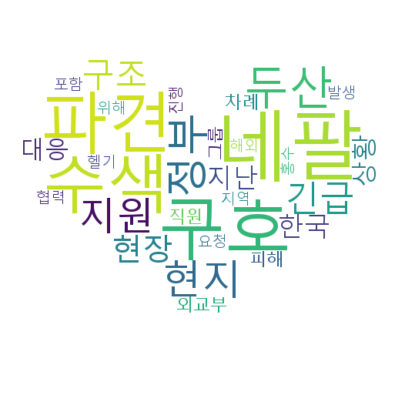

In [14]:
file_path = './data/news_content.txt'

with open(file_path, 'r', encoding='utf-8') as f:
    news_content = f.read()

# print(news_content)

# Okt 형태소 분석기 인스턴스 생성
twitter = Okt()

# Okt의 pos() 함수를 이용해 문장을 (단어, 품사태그) 형태의 튜플 리스트로 변환
morph = twitter.pos(news_content)
# print(morph)

# 명사(Noun)만 선택적으로 추출
noun_list = []

for word, tag in morph:
    if tag in ['Noun']:
        noun_list.append(word)

# print(len(noun_list))

# 한 글자 외딴 단어를 제거하고 두 글자 이상인 명사만 필터링
noun_list = [n for n in noun_list if len(n) > 1]
# print(noun_list[:10])

# 단어 빈도수 카운트
counts = Counter(noun_list)
tags = counts.most_common(30)
# print(tags)

img = np.array(Image.open('./data/mask_image.jpg'))

# WordCloud 생성 및 시각화
wordcloud = WordCloud(mask=img, font_path='C:/Windows/Fonts/malgun.ttf', background_color='white', width=800, height=600)

# 딕셔너리 형태의 빈도 데이터를 입력받아 워드클라우드 이미지 생성
cloud = wordcloud.generate_from_frequencies(dict(tags))

# 캔버스 그래프 틀 생성 (가로 10인치, 세로 8인치)
plt.figure(figsize=(5, 5))

# 워드클라우드 이미지 축의 눈금(x, y축 척도)을 숨김 처리
plt.axis('off')

# 생성된 워드클라우드 이미지를 matplotlib 캔버스에 렌더링
plt.imshow(cloud, interpolation='bilinear')

# 최종 워드클라우드 시각화 출력
plt.show()